In [1]:
import os
import glob
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score, silhouette_samples, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_score, completeness_score, v_measure_score)

In [2]:
# ============ PENGATURAN (ubah sesuai data) ============
FOLDER = r"C:\Users\Timothy\Downloads\archive (17)"
MODEL = "pixel"                    # pixel (piksel mentah) | colorhist (histogram warna) | gabungan (warna + tepi)
UKURAN_PIXEL = 32                  # gambar di-resize ke UKURAN_PIXEL x UKURAN_PIXEL (untuk MODEL = "pixel")
GRAYSCALE = False                  # True = pakai abu-abu saja (fitur 3x lebih sedikit), cocok kalau warna tidak penting
PAKAI_SCALER = True                # True untuk "pixel"; False untuk "colorhist" / "gabungan"
DAFTAR_PCA = [20, 50]              # jumlah komponen PCA yang dicoba
DAFTAR_ALGO = ["kmeans", "agglo"]  # kmeans | agglo | gmm
DAFTAR_K = range(2, 11)            # k yang dicoba (kecilkan kalau data < 50)
K_MANUAL = 5                    # None = otomatis dari silhouette, atau isi angka (mis. 4)
MIN_UKURAN = 0.02                  # cluster < 2% data tidak boleh jadi pilihan terbaik
BUANG_DUPLIKAT = True              # buang gambar duplikat persis (isi file sama)
MIN_SISI = 32                      # buang gambar yang lebar/tingginya < ini (piksel). 0 = nonaktif
MIN_KONTRAS = 2                    # buang gambar hampir kosong (std abu-abu < ini). 0 = nonaktif
PERBAIKI_KONTRAS = False           # True = auto-contrast sebelum ekstraksi fitur (gambar terlalu gelap/pucat)
JUMLAH_CONTOH = 8                  # contoh gambar per cluster
MAKS_SIL = 5000                    # data > ini: silhouette dihitung dari sampel
SEED = 42
# ========================================================

np.random.seed(SEED)

In [3]:
# ---------- 1. Baca path gambar ----------
ekstensi = ("jpg", "jpeg", "png", "bmp", "webp")
semua_path = sorted(set(p for e in ekstensi + tuple(x.upper() for x in ekstensi)
                        for p in glob.glob(os.path.join(FOLDER, "**", f"*.{e}"), recursive=True)))
print("Jumlah file gambar:", len(semua_path))
assert len(semua_path) > 10, "Gambar tidak ketemu / terlalu sedikit, cek FOLDER"

Jumlah file gambar: 4317



Gambar dibuang saat preprocessing: {'rusak': 0, 'terlalu_kecil': 0, 'kosong': 0, 'duplikat': 6}

Gambar valid: 4311
         lebar   tinggi    rasio  ukuran_kb  brightness  kontras
count  4311.00  4311.00  4311.00    4311.00     4311.00  4311.00
mean    338.48   253.09     1.33      54.13      100.23    52.52
std     119.04    61.57     0.31      44.93       32.56    14.81
min     134.00    80.00     0.56       5.39        4.48    13.53
25%     240.00   214.00     1.29      24.06       79.16    41.85
50%     320.00   240.00     1.44      36.54       98.46    51.26
75%     500.00   329.00     1.50      67.85      119.05    62.47
max    1024.00   442.00     5.48     275.34      236.20   108.39

Format file:
 format
JPEG    4311
Name: count, dtype: int64

Jumlah per folder:
 folder
dandelion    1052
tulip         980
rose          784
daisy         764
sunflower     731
Name: count, dtype: int64


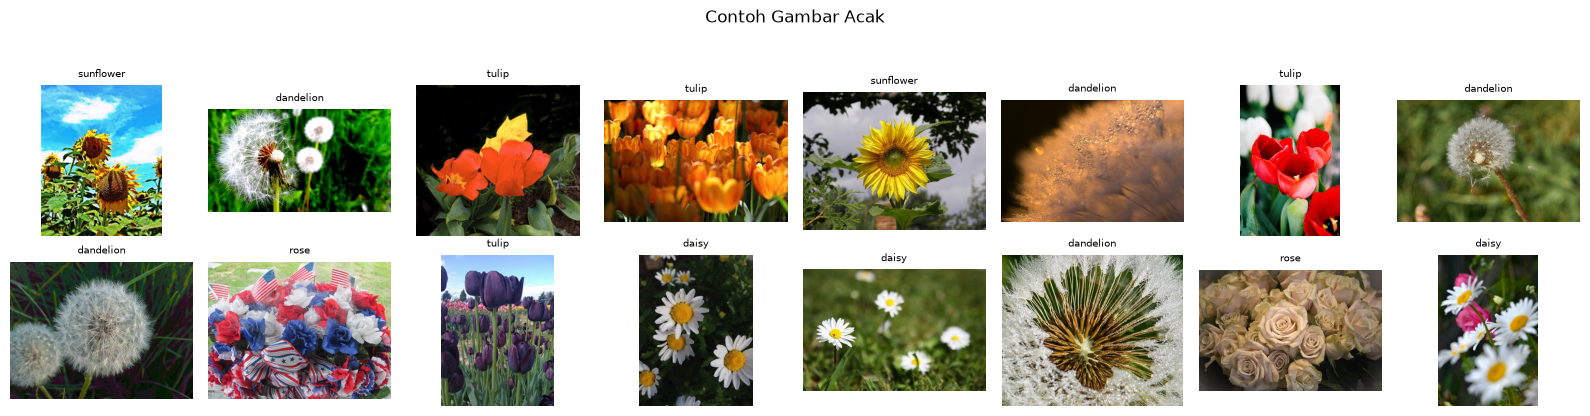

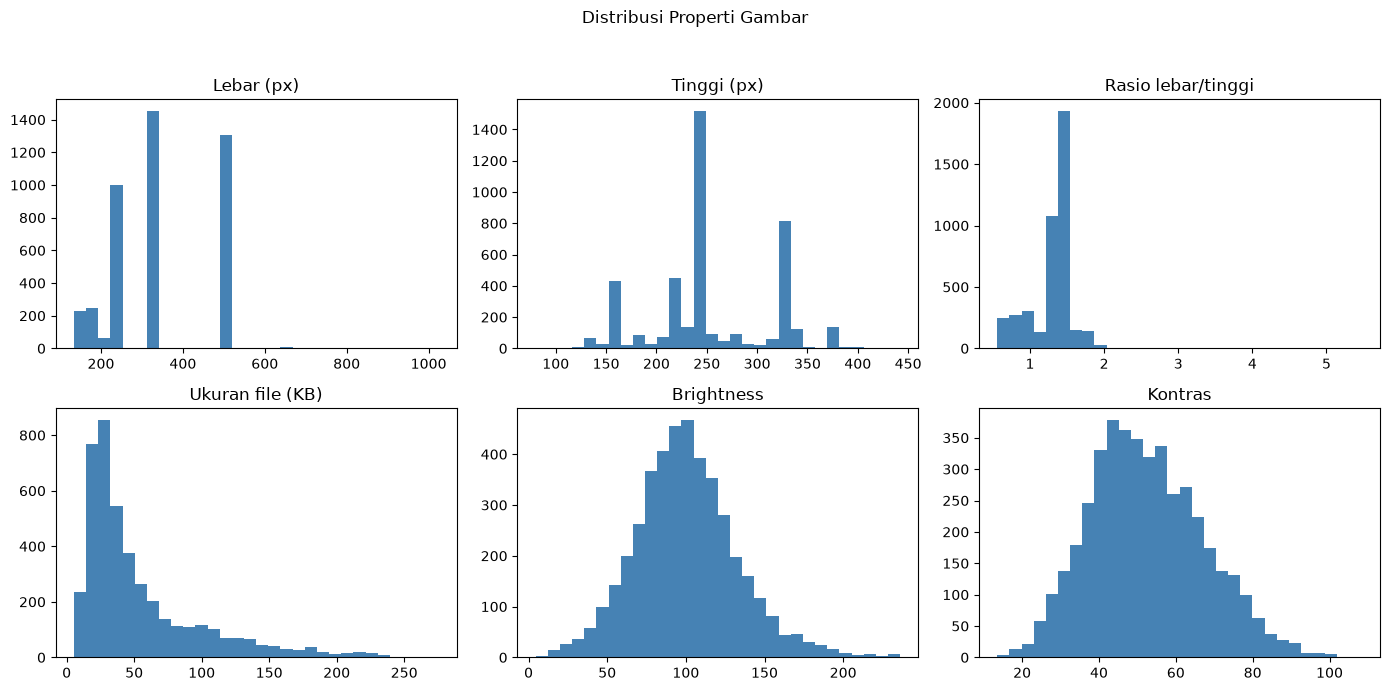

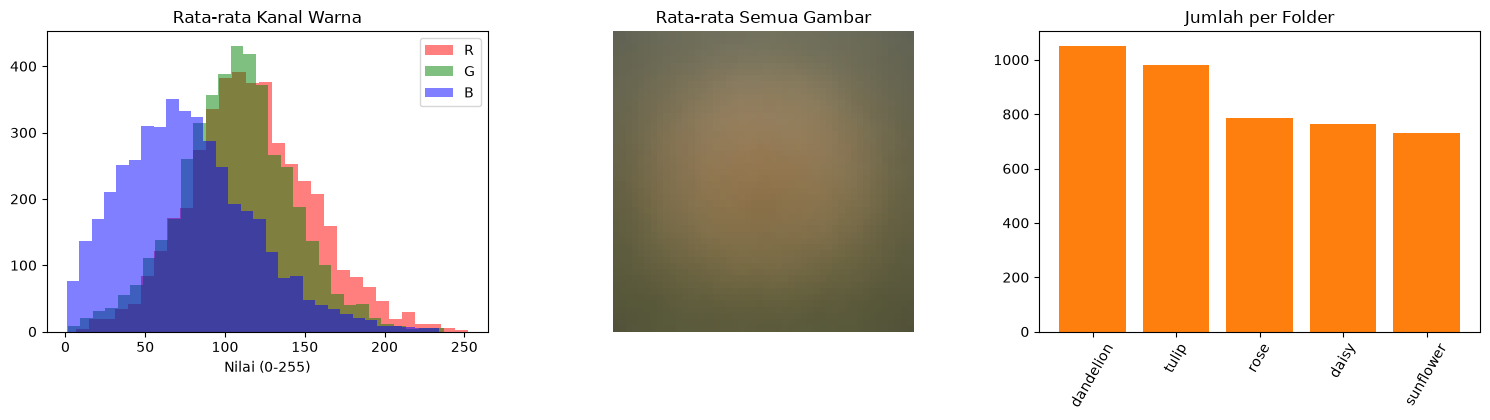

In [4]:
# ---------- 2. PREPROCESSING (filter gambar) + EDA ----------
def baca_info(path):
    with Image.open(path) as im:
        lebar, tinggi, fmt = im.width, im.height, im.format
        im.draft("RGB", (256, 256))
        im = im.convert("RGB")
    im.thumbnail((128, 128))
    a = np.asarray(im, dtype=np.float32)
    abu = a.mean(axis=2)
    info = dict(path=path, folder=os.path.basename(os.path.dirname(path)),
                lebar=lebar, tinggi=tinggi, rasio=lebar / tinggi,
                ukuran_kb=os.path.getsize(path) / 1024, format=fmt,
                brightness=abu.mean(), kontras=abu.std(),
                R=a[..., 0].mean(), G=a[..., 1].mean(), B=a[..., 2].mean())
    kecil = np.asarray(im.resize((48, 48)), dtype=np.float32) / 255
    return info, kecil


dibuang = {"rusak": 0, "terlalu_kecil": 0, "kosong": 0, "duplikat": 0}
hash_terlihat = set()
list_info, list_kecil, path_valid = [], [], []
for p in semua_path:
    try:
        info, kecil = baca_info(p)
    except Exception as e:
        print("Gambar rusak dilewati:", p, e)
        dibuang["rusak"] += 1
        continue
    if min(info["lebar"], info["tinggi"]) < MIN_SISI:
        dibuang["terlalu_kecil"] += 1
        continue
    if info["kontras"] < MIN_KONTRAS:
        dibuang["kosong"] += 1
        continue
    if BUANG_DUPLIKAT:
        with open(p, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        if h in hash_terlihat:
            dibuang["duplikat"] += 1
            continue
        hash_terlihat.add(h)
    list_info.append(info); list_kecil.append(kecil); path_valid.append(p)
print("\nGambar dibuang saat preprocessing:", dibuang)
assert len(path_valid) > 10, "Gambar valid terlalu sedikit, cek MIN_SISI / MIN_KONTRAS"

data_eda = pd.DataFrame(list_info)        # satu baris = satu gambar
gambar_kecil = np.stack(list_kecil)       # versi 48x48, dipakai untuk rata-rata gambar
punya_label = 1 < data_eda["folder"].nunique() <= 50   # subfolder dianggap label

print("\nGambar valid:", len(data_eda))
print(data_eda[["lebar", "tinggi", "rasio", "ukuran_kb", "brightness", "kontras"]].describe().round(2))
print("\nFormat file:\n", data_eda["format"].value_counts())
if punya_label:
    print("\nJumlah per folder:\n", data_eda["folder"].value_counts())

# contoh gambar acak
idx = np.random.RandomState(SEED).choice(len(path_valid), size=min(16, len(path_valid)), replace=False)
kolom = min(8, len(idx)); baris = int(np.ceil(len(idx) / kolom))
fig, axes = plt.subplots(baris, kolom, figsize=(2 * kolom, 2.1 * baris), squeeze=False)
for a in axes.ravel():
    a.axis("off")
for a, i in zip(axes.ravel(), idx):
    a.imshow(Image.open(path_valid[i]).convert("RGB"))
    a.set_title(data_eda["folder"][i][:16], fontsize=7)
fig.suptitle("Contoh Gambar Acak"); fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

# distribusi properti
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for a, (kol, judul) in zip(axes.ravel(), [("lebar", "Lebar (px)"), ("tinggi", "Tinggi (px)"),
                                          ("rasio", "Rasio lebar/tinggi"), ("ukuran_kb", "Ukuran file (KB)"),
                                          ("brightness", "Brightness"), ("kontras", "Kontras")]):
    a.hist(data_eda[kol], bins=30, color="steelblue"); a.set_title(judul)
fig.suptitle("Distribusi Properti Gambar"); fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

# warna, rata-rata gambar, jumlah per folder
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
for kanal, warna in zip(["R", "G", "B"], ["red", "green", "blue"]):
    ax[0].hist(data_eda[kanal], bins=30, alpha=.5, color=warna, label=kanal)
ax[0].set(title="Rata-rata Kanal Warna", xlabel="Nilai (0-255)"); ax[0].legend()
ax[1].imshow(gambar_kecil.mean(axis=0)); ax[1].axis("off"); ax[1].set_title("Rata-rata Semua Gambar")
jumlah = data_eda["folder"].value_counts().head(20) if punya_label else data_eda["format"].value_counts()
ax[2].bar(jumlah.index.astype(str), jumlah.values, color="tab:orange"); ax[2].tick_params(axis="x", rotation=60)
ax[2].set_title("Jumlah per Folder" if punya_label else "Format File")
fig.tight_layout(); plt.show()

In [5]:
# ---------- 3. Ekstraksi fitur ----------
def buka(path):
    im = Image.open(path).convert("RGB")
    if PERBAIKI_KONTRAS:
        im = ImageOps.autocontrast(im, cutoff=1)     # regangkan kontras, abaikan 1% piksel ekstrem
    return im


def fitur_warna(im):
    """Histogram warna HSV (8x4x4 = 128 fitur), dinormalisasi jadi proporsi."""
    hsv = np.asarray(im.resize((128, 128)).convert("HSV")).reshape(-1, 3)
    h, _ = np.histogramdd(hsv, bins=(8, 4, 4), range=((0, 256),) * 3)
    return h.ravel() / h.sum()


def fitur_tepi(im):
    g = np.asarray(im.resize((128, 128)).convert("L"), dtype=np.float32)
    gy, gx = np.gradient(g)
    e, _ = np.histogram(np.arctan2(gy, gx), bins=16, range=(-np.pi, np.pi), weights=np.hypot(gx, gy))
    return e / (e.sum() + 1e-9)


def ambil_fitur(daftar_path, nama_model):
    hasil = []
    for i, p in enumerate(daftar_path):
        im = buka(p)
        if nama_model == "pixel":          # piksel mentah, seperti pendekatan load_digits
            kecil = im.convert("L") if GRAYSCALE else im
            hasil.append(np.asarray(kecil.resize((UKURAN_PIXEL, UKURAN_PIXEL)), dtype=np.float32).ravel() / 255)
        elif nama_model == "colorhist":
            hasil.append(fitur_warna(im))
        elif nama_model == "gabungan":
            hasil.append(np.concatenate([fitur_warna(im), fitur_tepi(im)]))
        else:
            raise ValueError("MODEL tidak dikenal: " + nama_model)
        if (i + 1) % 200 == 0 or i + 1 == len(daftar_path):
            print(f"  fitur {i + 1}/{len(daftar_path)}", end="\r")
    return np.array(hasil)


X = ambil_fitur(path_valid, MODEL)
print("\nBentuk fitur:", X.shape)

  fitur 4311/4311
Bentuk fitur: (4311, 3072)


In [6]:
# ---------- 4. Scaling + PCA ----------
X_scaled = StandardScaler().fit_transform(X) if PAKAI_SCALER else X
data_pca = {}
for jml in DAFTAR_PCA:
    jml = min(jml, X_scaled.shape[0] - 1, X_scaled.shape[1])
    pca = PCA(n_components=jml, random_state=SEED)
    data_pca[jml] = pca.fit_transform(X_scaled)
    print(f"PCA {jml} komponen -> variance dijelaskan {pca.explained_variance_ratio_.sum():.2%}")

PCA 20 komponen -> variance dijelaskan 67.34%
PCA 50 komponen -> variance dijelaskan 77.23%


In [7]:
def buat_model(algo, k):
    if algo == "kmeans":
        return KMeans(n_clusters=k, n_init=10, random_state=SEED)
    if algo == "agglo":
        return AgglomerativeClustering(n_clusters=k, linkage="ward")
    if algo == "gmm":
        return GaussianMixture(n_components=k, covariance_type="diag", random_state=SEED)
    raise ValueError("algo tidak dikenal: " + algo)


def hitung_sil(Xp, lab):
    sampel = MAKS_SIL if len(Xp) > MAKS_SIL else None
    return silhouette_score(Xp, lab, sample_size=sampel, random_state=SEED)


baris = []
for jml, Xp in data_pca.items():
    for algo in DAFTAR_ALGO:
        for k in DAFTAR_K:
            model = buat_model(algo, k)
            lab = model.fit_predict(Xp)
            if len(set(lab)) < 2:
                continue
            baris.append(dict(n_pca=jml, algo=algo, k=k, silhouette=hitung_sil(Xp, lab),
                              davies_bouldin=davies_bouldin_score(Xp, lab),
                              calinski=calinski_harabasz_score(Xp, lab),
                              inertia=getattr(model, "inertia_", np.nan),
                              cluster_terkecil=int(np.bincount(lab).min())))
hasil_percobaan = pd.DataFrame(baris)

print("\n=== 15 percobaan terbaik (urut silhouette) ===")
print(hasil_percobaan.sort_values("silhouette", ascending=False).head(15).round(4).to_string(index=False))
print("\n=== Terbaik untuk tiap (algo, n_pca) ===")
print(hasil_percobaan.loc[hasil_percobaan.groupby(["algo", "n_pca"]).silhouette.idxmax()].round(4).to_string(index=False))

kandidat = hasil_percobaan if K_MANUAL is None else hasil_percobaan[hasil_percobaan.k == K_MANUAL]
kandidat_aman = kandidat[kandidat.cluster_terkecil >= max(2, MIN_UKURAN * len(X))]
if len(kandidat_aman) > 0:
    kandidat = kandidat_aman
terbaik = kandidat.sort_values("silhouette", ascending=False).iloc[0]
algo_terbaik, k_terbaik, pca_terbaik = terbaik.algo, int(terbaik.k), int(terbaik.n_pca)
Xp = data_pca[pca_terbaik]
print(f"\n>>> Dipilih: algo={algo_terbaik}, n_pca={pca_terbaik}, k={5} (silhouette={terbaik.silhouette:.4f})")


=== 15 percobaan terbaik (urut silhouette) ===
 n_pca   algo  k  silhouette  davies_bouldin  calinski   inertia  cluster_terkecil
    20 kmeans  2      0.2028          1.7492 1282.1443 6872575.0              1777
    50 kmeans  2      0.1791          1.9220 1076.8776 8182930.5              1775
    20 kmeans  3      0.1355          2.0265  943.3426 6201547.5               754
    20  agglo  2      0.1341          2.0160  903.5714       NaN              1799
    20 kmeans  5      0.1270          2.0396  683.0852 5455663.0               526
    20 kmeans  4      0.1220          2.1975  767.8886 5809979.0               616
    50  agglo  2      0.1211          1.9922  749.3746       NaN              1219
    20 kmeans  6      0.1197          2.0839  604.8239 5237994.0               550
    50 kmeans  3      0.1149          2.2554  779.0310 7511350.0               766
    20  agglo  3      0.1129          2.0511  714.1857       NaN               306
    50 kmeans  5      0.1075          2


=== Elbow (KMeans) ===
  n_pca=20: elbow di k = 5
  n_pca=50: elbow di k = 5


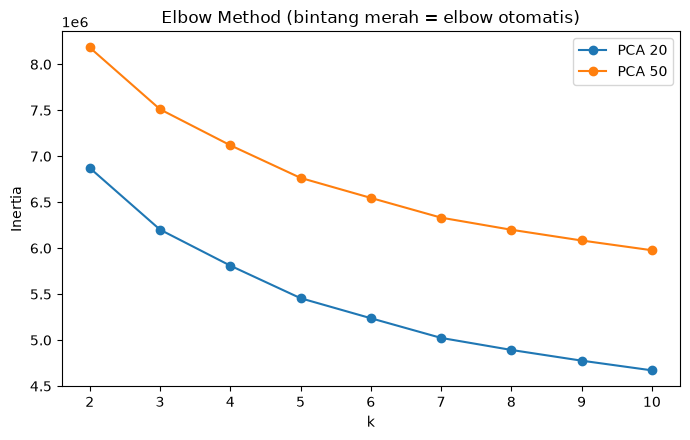

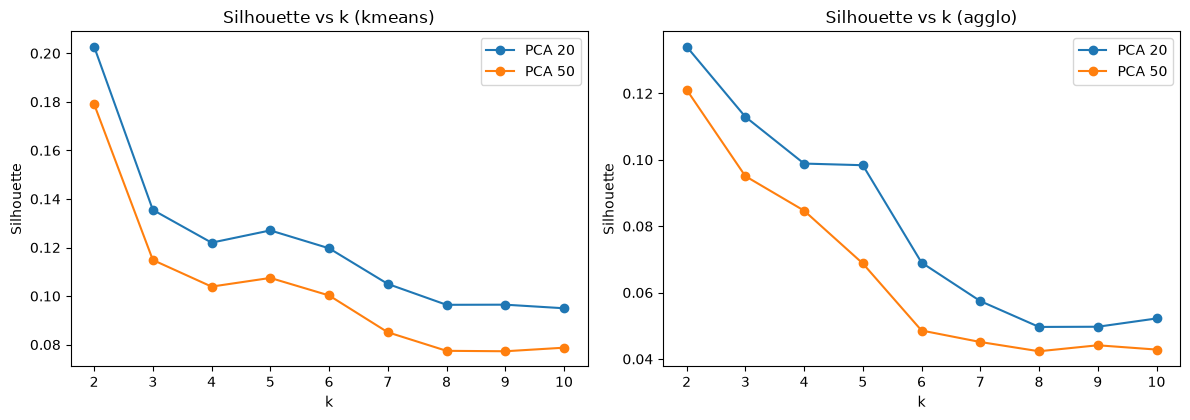

In [8]:
# ---------- 6. Plot elbow dan silhouette vs k ----------
def cari_elbow(ks, ys):
    """Titik yang paling jauh dari garis lurus ujung-ke-ujung kurva."""
    ks, ys = np.array(ks, float), np.array(ys, float)
    if len(ks) < 3 or ys.max() == ys.min():
        return int(ks[0])
    x = (ks - ks.min()) / (ks.max() - ks.min())
    y = (ys - ys.min()) / (ys.max() - ys.min())
    return int(ks[np.abs(x + y - 1).argmax()])


if "kmeans" in DAFTAR_ALGO:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    print("\n=== Elbow (KMeans) ===")
    for jml in data_pca:
        d = hasil_percobaan[(hasil_percobaan.algo == "kmeans") & (hasil_percobaan.n_pca == jml)].sort_values("k")
        ax.plot(d.k, d.inertia, "o-", label=f"PCA {jml}")
        k_elbow = cari_elbow(d.k, d.inertia)
        print(f"  n_pca={jml}: elbow di k = {k_elbow}")
    ax.set(title="Elbow Method (bintang merah = elbow otomatis)", xlabel="k", ylabel="Inertia")
    ax.legend(); fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(DAFTAR_ALGO), figsize=(6 * len(DAFTAR_ALGO), 4.3), squeeze=False)
for a, algo in zip(axes[0], DAFTAR_ALGO):
    for jml in data_pca:
        d = hasil_percobaan[(hasil_percobaan.algo == algo) & (hasil_percobaan.n_pca == jml)].sort_values("k")
        a.plot(d.k, d.silhouette, "o-", label=f"PCA {jml}")
    a.set(title=f"Silhouette vs k ({algo})", xlabel="k", ylabel="Silhouette"); a.legend()
fig.tight_layout(); plt.show()


Silhouette Score  : 0.1270
Davies-Bouldin    : 2.0396  (makin kecil makin bagus)
Calinski-Harabasz : 683.09  (makin besar makin bagus)

Jumlah gambar per cluster:
 cluster
0    1133
1     681
2    1140
3     831
4     526
Name: count, dtype: int64

Rata-rata silhouette per cluster:
 cluster
0    0.0704
1    0.1255
2    0.1893
3    0.1200
4    0.1272
Name: silhouette, dtype: float32


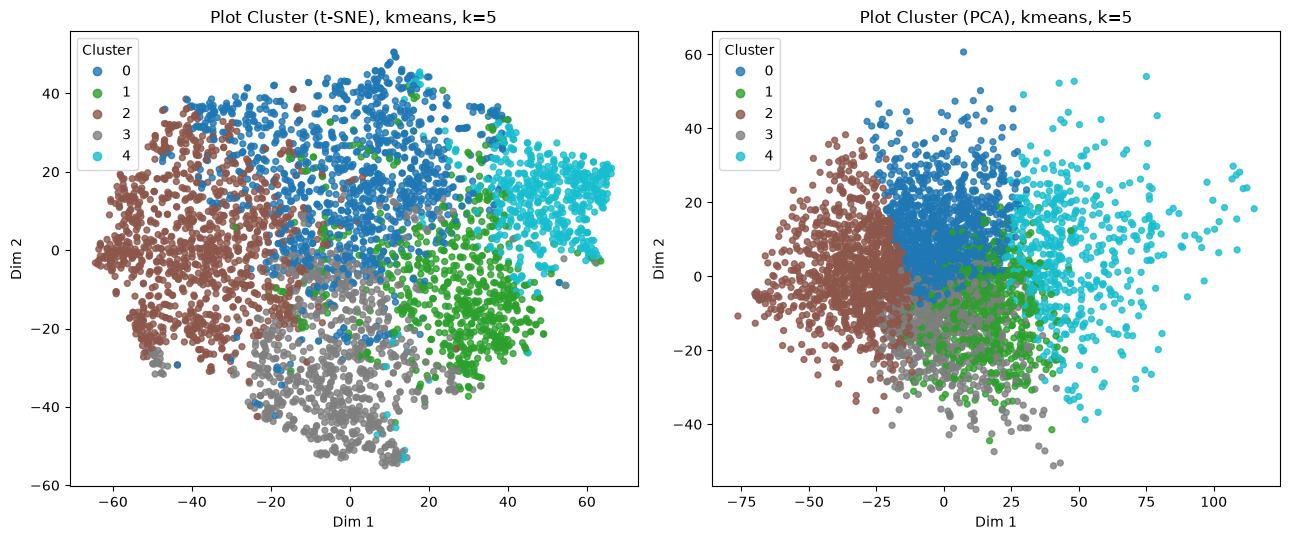

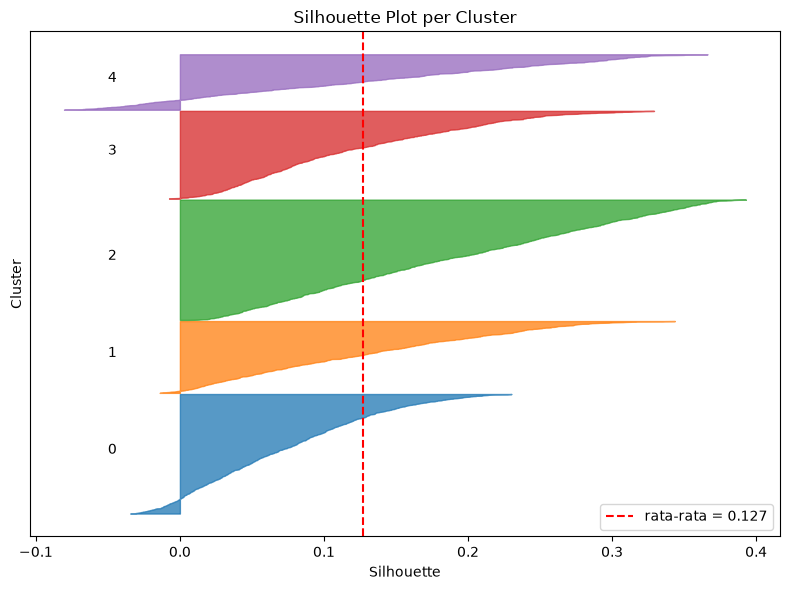

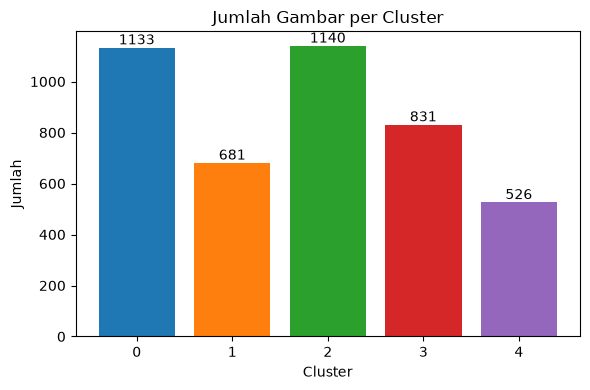

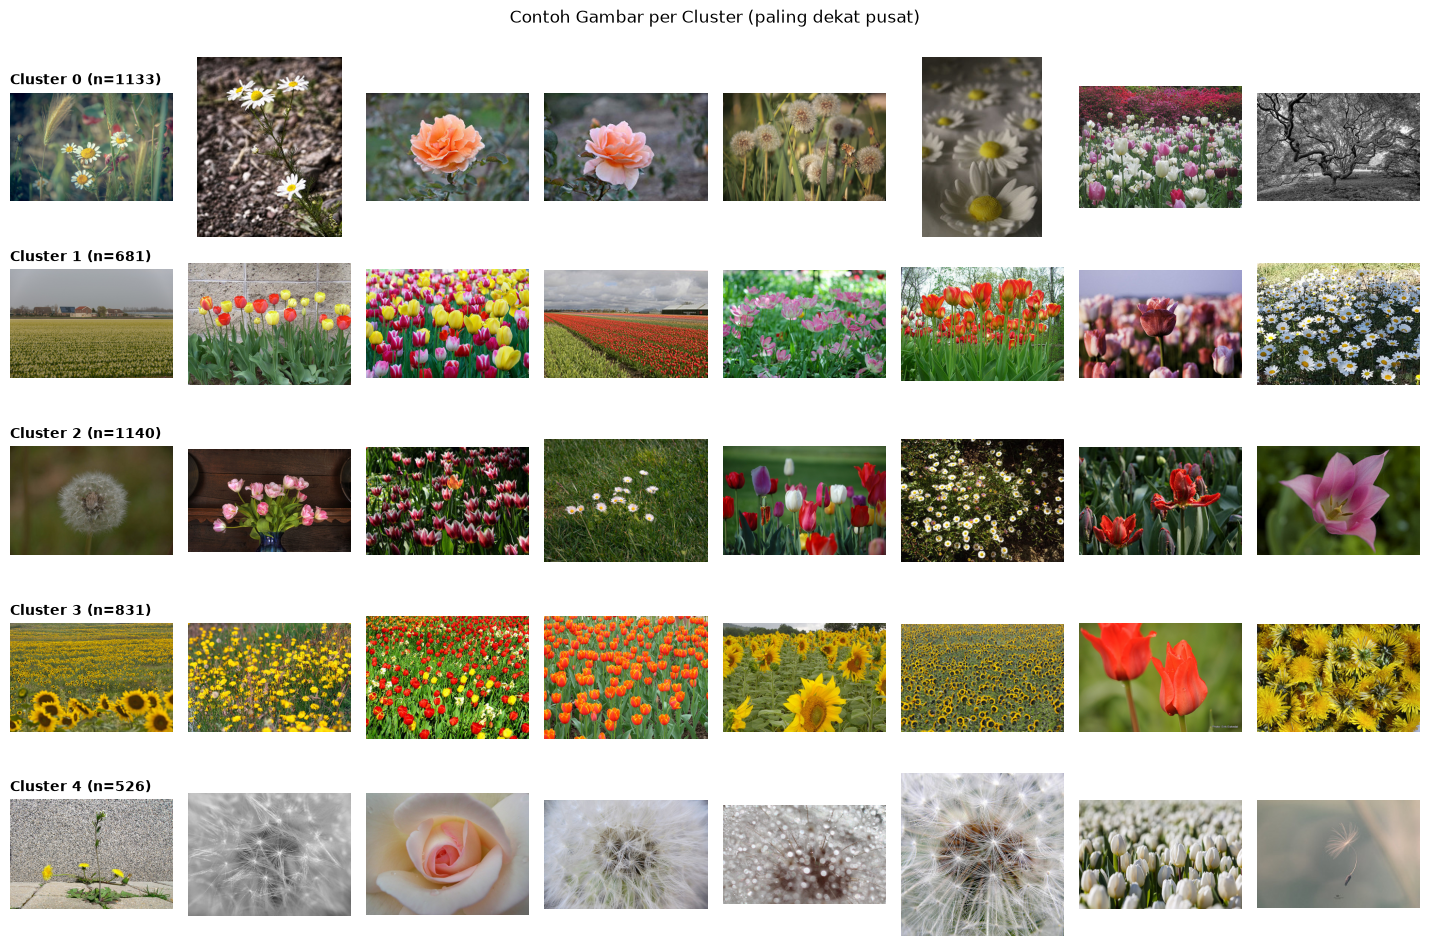

In [9]:
# ---------- 7. Model final + evaluasi ----------
label = buat_model(algo_terbaik, 5).fit_predict(Xp)
sil_total = silhouette_score(Xp, label)
sil_sampel = silhouette_samples(Xp, label)
print(f"\nSilhouette Score  : {sil_total:.4f}")
print(f"Davies-Bouldin    : {davies_bouldin_score(Xp, label):.4f}  (makin kecil makin bagus)")
print(f"Calinski-Harabasz : {calinski_harabasz_score(Xp, label):.2f}  (makin besar makin bagus)")

data_eda["cluster"] = label
data_eda["silhouette"] = sil_sampel
daftar_cluster = sorted(set(label))
print("\nJumlah gambar per cluster:\n", data_eda["cluster"].value_counts().sort_index())
print("\nRata-rata silhouette per cluster:\n", data_eda.groupby("cluster")["silhouette"].mean().round(4))

# plot cluster 2D
tsne = TSNE(n_components=2, perplexity=max(2, min(30, (len(Xp) - 1) / 3)),
            random_state=SEED, init="pca", learning_rate="auto").fit_transform(Xp)
pca2 = PCA(n_components=2, random_state=SEED).fit_transform(Xp)
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
for a, hasil_2d, nama in zip(ax, [tsne, pca2], ["t-SNE", "PCA"]):
    sc = a.scatter(hasil_2d[:, 0], hasil_2d[:, 1], c=label, cmap="tab10", s=18, alpha=.8)
    a.set(title=f"Plot Cluster ({nama}), {algo_terbaik}, k={k_terbaik}", xlabel="Dim 1", ylabel="Dim 2")
    a.legend(*sc.legend_elements(), title="Cluster")
fig.tight_layout(); plt.show()

# silhouette plot
fig, ax = plt.subplots(figsize=(8, 6))
bawah = 10
for c in daftar_cluster:
    s = np.sort(sil_sampel[label == c]); atas = bawah + len(s)
    ax.fill_betweenx(np.arange(bawah, atas), 0, s, alpha=.75, color=plt.cm.tab10(c % 10))
    ax.text(-0.05, bawah + .5 * len(s), str(c)); bawah = atas + 10
ax.axvline(sil_total, c="red", ls="--", label=f"rata-rata = {sil_total:.3f}")
ax.set(title="Silhouette Plot per Cluster", xlabel="Silhouette", ylabel="Cluster", yticks=[])
ax.legend(); fig.tight_layout(); plt.show()

# ukuran cluster
jumlah = data_eda["cluster"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(jumlah.index.astype(str), jumlah.values, color=[plt.cm.tab10(i % 10) for i in jumlah.index])
for i, v in enumerate(jumlah.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set(title="Jumlah Gambar per Cluster", xlabel="Cluster", ylabel="Jumlah")
fig.tight_layout(); plt.show()

# contoh gambar per cluster (yang paling dekat pusat cluster)
fig, axes = plt.subplots(len(daftar_cluster), JUMLAH_CONTOH,
                         figsize=(1.8 * JUMLAH_CONTOH, 1.9 * len(daftar_cluster)), squeeze=False)
for baris_ke, c in enumerate(daftar_cluster):
    anggota = np.where(label == c)[0]
    pusat = Xp[anggota].mean(axis=0)
    terdekat = anggota[np.argsort(np.linalg.norm(Xp[anggota] - pusat, axis=1))[:JUMLAH_CONTOH]]
    for j in range(JUMLAH_CONTOH):
        a = axes[baris_ke, j]; a.axis("off")
        if j < len(terdekat):
            a.imshow(Image.open(path_valid[terdekat[j]]).convert("RGB"))
        if j == 0:
            a.set_title(f"Cluster {c} (n={len(anggota)})", loc="left", fontsize=10, fontweight="bold")
fig.suptitle("Contoh Gambar per Cluster (paling dekat pusat)", y=1.0)
fig.tight_layout(); plt.show()


Rata-rata properti per cluster:
          brightness    kontras  rasio  ukuran_kb           R           G  \
cluster                                                                    
0        102.709999  56.310001   1.33      51.40  110.580002  108.360001   
1        115.559998  60.590000   1.32      60.27  128.580002  120.269997   
2         62.709999  49.880001   1.36      47.74   76.150002   68.680000   
3         99.860001  43.959999   1.34      64.74  140.539993  113.870003   
4        156.940002  53.200001   1.29      49.17  167.309998  159.770004   

                  B  
cluster              
0         89.190002  
1         97.820000  
2         43.290001  
3         45.160000  
4        143.740005  


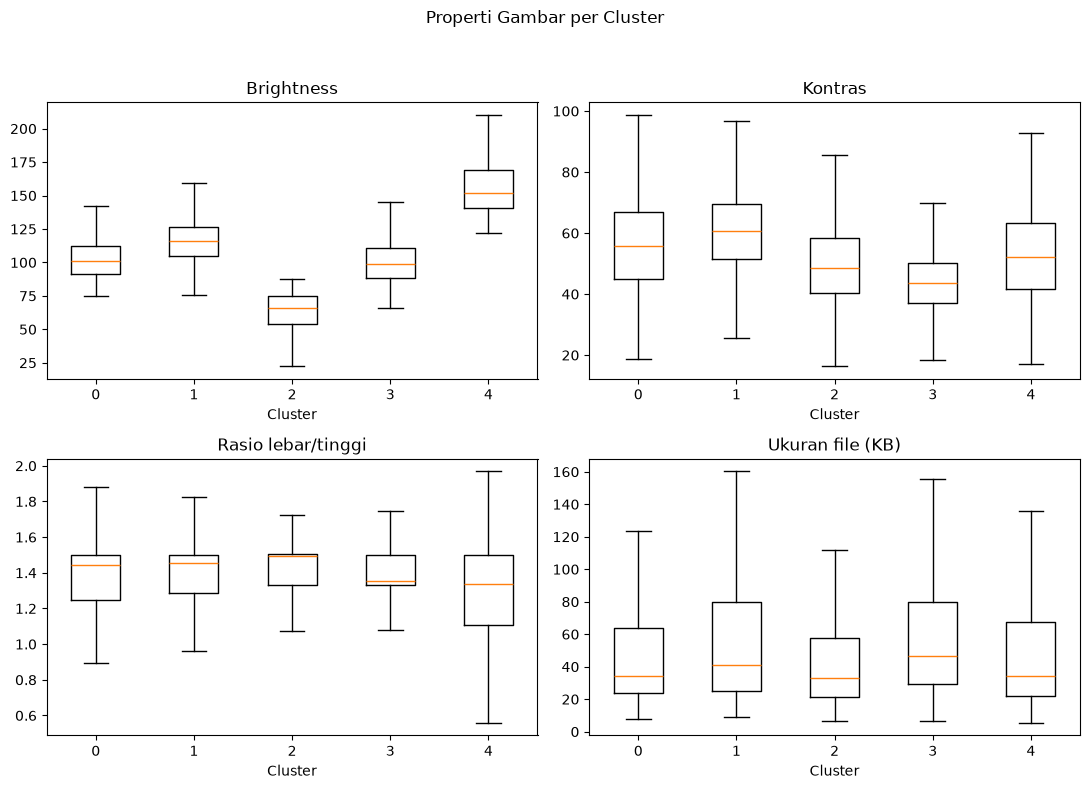

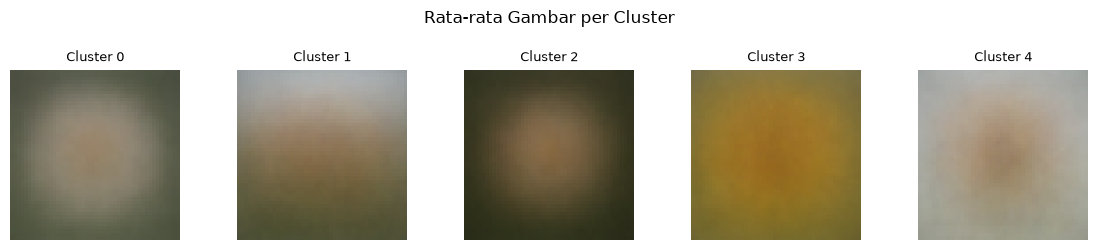

In [10]:
# ---------- 8. EDA per cluster ----------
print("\nRata-rata properti per cluster:\n",
      data_eda.groupby("cluster")[["brightness", "kontras", "rasio", "ukuran_kb", "R", "G", "B"]].mean().round(2))

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for a, (kol, judul) in zip(axes.ravel(), [("brightness", "Brightness"), ("kontras", "Kontras"),
                                          ("rasio", "Rasio lebar/tinggi"), ("ukuran_kb", "Ukuran file (KB)")]):
    a.boxplot([data_eda.loc[data_eda.cluster == c, kol] for c in daftar_cluster], showfliers=False)
    a.set_xticklabels([str(c) for c in daftar_cluster]); a.set(title=judul, xlabel="Cluster")
fig.suptitle("Properti Gambar per Cluster"); fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

kolom = min(8, len(daftar_cluster)); baris = int(np.ceil(len(daftar_cluster) / kolom))
fig, axes = plt.subplots(baris, kolom, figsize=(2.3 * kolom, 2.5 * baris), squeeze=False)
for a in axes.ravel():
    a.axis("off")
for a, c in zip(axes.ravel(), daftar_cluster):
    a.imshow(gambar_kecil[label == c].mean(axis=0)); a.set_title(f"Cluster {c}", fontsize=9)
fig.suptitle("Rata-rata Gambar per Cluster"); fig.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()


=== EVALUASI EKSTERNAL (vs nama subfolder) ===
Crosstab cluster x label:
 col_0    daisy  dandelion  rose  sunflower  tulip
cluster                                          
0          298        313   220         79    223
1           63        123   104        181    210
2          257        319   243         77    244
3           34        185   104        307    201
4          112        112   113         87    102

Purity per cluster:
             n label_dominan  purity
cluster                            
0        1133     dandelion  0.2763
1         681         tulip  0.3084
2        1140     dandelion  0.2798
3         831     sunflower  0.3694
4         526          rose  0.2148

Purity (overall)   : 0.2927  (1 = tiap cluster berisi satu label saja)
Adjusted Rand Index: 0.0336  (1 = cocok sempurna, ~0 = acak)
NMI                : 0.0480  (1 = cocok sempurna)
Homogeneity        : 0.0476  (tiap cluster berisi satu label)
Completeness       : 0.0485  (satu label tidak terpecah 

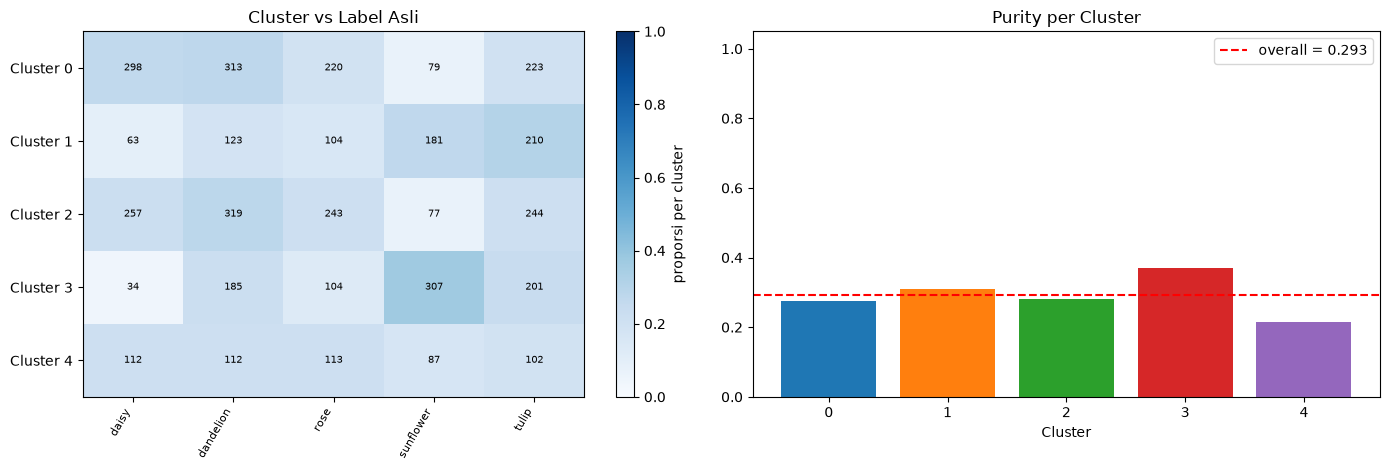

In [11]:
# ---------- EVALUASI EKSTERNAL (bandingkan cluster dengan label asli) ----------
def evaluasi_eksternal(label_asli, label_cluster, nama_label):
    """Purity, ARI, NMI, homogeneity, completeness, V-measure + crosstab & heatmap.
    Label asli HANYA dipakai untuk menilai hasil, bukan untuk clustering."""
    label_asli = pd.Series(np.asarray(label_asli)).astype(str)
    label_cluster = pd.Series(np.asarray(label_cluster))
    tabel = pd.crosstab(label_cluster, label_asli); tabel.index.name = "cluster"
    purity_c = tabel.max(axis=1) / tabel.sum(axis=1)
    ringkas = pd.DataFrame({"n": tabel.sum(axis=1), "label_dominan": tabel.idxmax(axis=1),
                            "purity": purity_c.round(4)})
    purity_total = tabel.max(axis=1).sum() / tabel.values.sum()

    print(f"\n=== EVALUASI EKSTERNAL (vs {nama_label}) ===")
    print("Crosstab cluster x label:\n", tabel)
    print("\nPurity per cluster:\n", ringkas.to_string())
    print(f"\nPurity (overall)   : {purity_total:.4f}  (1 = tiap cluster berisi satu label saja)")
    print(f"Adjusted Rand Index: {adjusted_rand_score(label_asli, label_cluster):.4f}  (1 = cocok sempurna, ~0 = acak)")
    print(f"NMI                : {normalized_mutual_info_score(label_asli, label_cluster):.4f}  (1 = cocok sempurna)")
    print(f"Homogeneity        : {homogeneity_score(label_asli, label_cluster):.4f}  (tiap cluster berisi satu label)")
    print(f"Completeness       : {completeness_score(label_asli, label_cluster):.4f}  (satu label tidak terpecah ke banyak cluster)")
    print(f"V-measure          : {v_measure_score(label_asli, label_cluster):.4f}  (gabungan keduanya)")
    if label_asli.nunique() > label_cluster.nunique():
        print("Catatan: jumlah label asli > jumlah cluster, purity wajar rendah dan completeness tidak bisa tinggi.")
    if label_cluster.nunique() > label_asli.nunique():
        print("Catatan: purity cenderung naik kalau jumlah cluster diperbanyak, jangan dipakai sendirian.")

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
    norm = tabel.div(tabel.sum(axis=1), axis=0)
    im = ax[0].imshow(norm.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax[0].set_xticks(range(norm.shape[1])); ax[0].set_xticklabels([str(c)[:14] for c in norm.columns], rotation=60, ha="right", fontsize=8)
    ax[0].set_yticks(range(norm.shape[0])); ax[0].set_yticklabels([f"Cluster {c}" for c in norm.index])
    if norm.shape[0] * norm.shape[1] <= 120:
        for i in range(norm.shape[0]):
            for j in range(norm.shape[1]):
                ax[0].text(j, i, str(tabel.values[i, j]), ha="center", va="center", fontsize=7,
                           color="white" if norm.values[i, j] > .55 else "black")
    fig.colorbar(im, ax=ax[0], label="proporsi per cluster"); ax[0].set_title("Cluster vs Label Asli")
    ax[1].bar([str(c) for c in purity_c.index], purity_c.values, color=[plt.cm.tab10(int(i) % 10) for i in purity_c.index])
    ax[1].axhline(purity_total, c="red", ls="--", label=f"overall = {purity_total:.3f}")
    ax[1].set(title="Purity per Cluster", xlabel="Cluster", ylim=(0, 1.05)); ax[1].legend()
    fig.tight_layout(); plt.show()
    return ringkas


if punya_label:       # bermakna kalau nama subfolder = label asli
    evaluasi_eksternal(data_eda.folder, data_eda.cluster, "nama subfolder")
else:
    print("\nTidak ada label asli (gambar tidak dibagi per subfolder) -> evaluasi eksternal dilewati.")